# HW12 — Временные ряды: temporal split, baseline-модели и GRU-прогноз

Домашняя работа к семинару 12 курса «Инженерия Искусственного Интеллекта».

**Цель:** закрепить корректную работу с временными рядами — temporal split, лаговые признаки, сравнение baseline-моделей с GRU.

## 1. Импорты, seed и среда

In [1]:
import math
import random
import json
import os
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Пути к артефактам
ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Библиотеки импортированы.")

Библиотеки импортированы.


In [2]:
# Фиксируем seed для воспроизводимости
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seed: {SEED}")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Seed: 42
Device: cpu
PyTorch: 2.10.0+cpu


## 2. Данные и первичный анализ

In [3]:
# Загрузка датасета
DATA_PATH = "../../FORYOU/S12-hw-dataset.csv"
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Число наблюдений: {len(df)}")
print(f"Диапазон дат: {df['date'].min()} — {df['date'].max()}")
print(f"Частота: часовые данные (шаг ~1 час)")
print(f"\nПропуски по колонкам:")
print(df.isnull().sum())
print(f"\nОписательная статистика:")
display(df.describe())
df.head(10)

Число наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Частота: часовые данные (шаг ~1 час)

Пропуски по колонкам:
date      0
target    0
dtype: int64

Описательная статистика:


,date,target
count,4320,4320.000000
mean,2025-03-31 23:30:00,135.605840
min,2025-01-01 00:00:00,69.100000
25%,2025-02-14 23:45:00,120.537500
50%,2025-03-31 23:30:00,135.835000
75%,2025-05-15 23:15:00,150.625000
max,2025-06-29 23:00:00,210.100000
std,NaN,21.384633


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62
5,2025-01-01 05:00:00,117.29
6,2025-01-01 06:00:00,126.50
7,2025-01-01 07:00:00,126.01
8,2025-01-01 08:00:00,122.38
9,2025-01-01 09:00:00,128.28


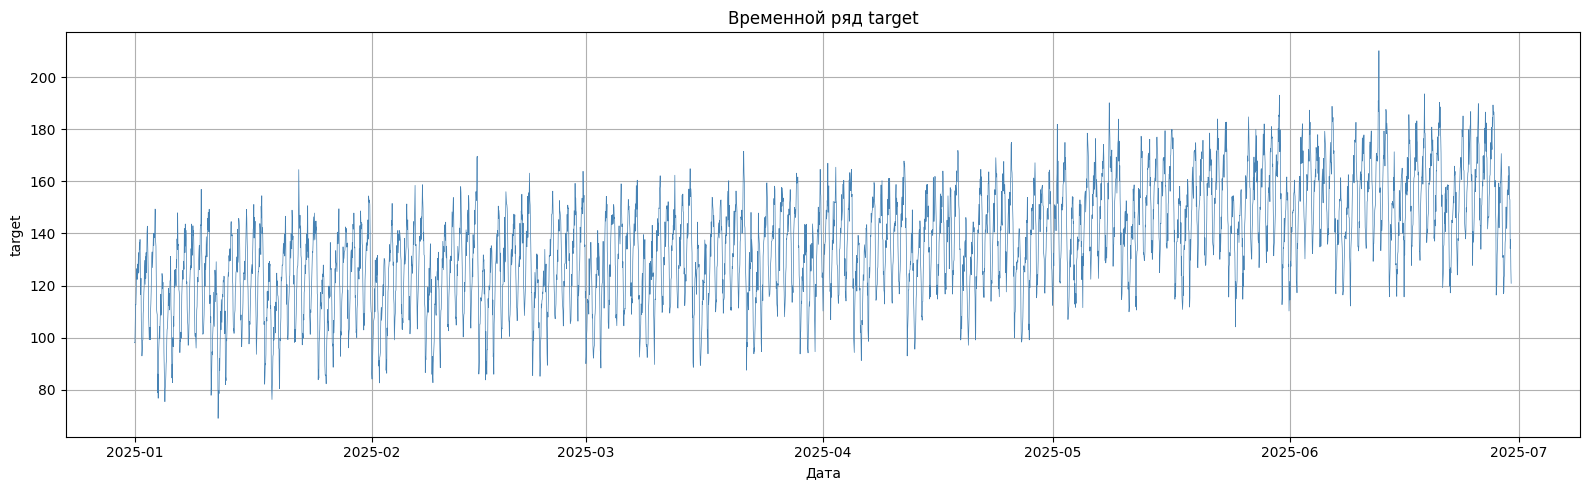

In [4]:
# Базовый график временного ряда
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df["date"], df["target"], linewidth=0.5, color="steelblue")
ax.set_title("Временной ряд target")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
plt.tight_layout()
plt.show()

**Комментарий по данным:**

Ряд представляет часовые наблюдения за ~180 дней (январь–июнь 2025). Наблюдается выраженная суточная сезонность: значения растут в дневные часы и снижаются ночью. Присутствует лёгкий положительный тренд. Явных выбросов и пропусков не обнаружено. Данные выглядят стационарными в пределах сезонных колебаний, что делает ряд подходящим для прогнозирования.

## 3. Корректный temporal split

**Почему random split здесь некорректен:**

При работе с временными рядами случайное перемешивание нарушает временную структуру: модель получает доступ к будущим наблюдениям при обучении, что создаёт нереалистично оптимистичную оценку качества (leakage). В реальной эксплуатации модель всегда прогнозирует будущее на основе прошлого, поэтому разбиение должно строго следовать хронологии: train → validation → test.

In [5]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

split_cfg = SplitConfig()
train_df, val_df, test_df = temporal_split(df, split_cfg)

print(f"train: {train_df['date'].min()} — {train_df['date'].max()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min()} — {val_df['date'].max()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min()} — {test_df['date'].max()} | {len(test_df)} строк")

split_summary = f"train={len(train_df)}/val={len(val_df)}/test={len(test_df)}"

train: 2025-01-01 00:00:00 — 2025-05-06 23:00:00 | 3024 строк
val:   2025-05-07 00:00:00 — 2025-06-02 23:00:00 | 648 строк
test:  2025-06-03 00:00:00 — 2025-06-29 23:00:00 | 648 строк


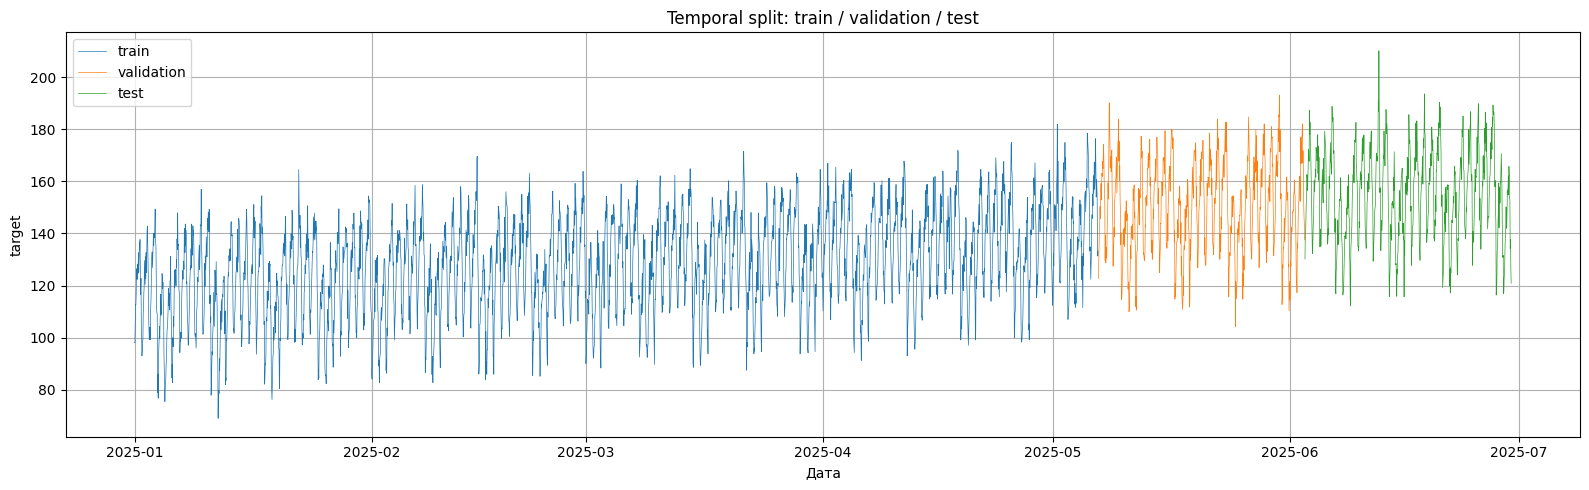

Сохранено: artifacts/figures/series_split.png


In [6]:
# Визуализация split
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_df["date"], train_df["target"], label="train", linewidth=0.5)
ax.plot(val_df["date"], val_df["target"], label="validation", linewidth=0.5)
ax.plot(test_df["date"], test_df["target"], label="test", linewidth=0.5)
ax.set_title("Temporal split: train / validation / test")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "series_split.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/figures/series_split.png")

## 4. Признаки для baseline-моделей

In [7]:
def add_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    """Добавляет лаговые, rolling и календарные признаки."""
    out = df.copy()
    
    # Лаговые признаки (смотрят только назад)
    for lag in [1, 7, 14]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)
    
    # Rolling-признаки (shift(1) чтобы не включать текущее наблюдение)
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    
    # Календарные признаки
    out["dayofweek"] = out["date"].dt.dayofweek
    out["hour"] = out["date"].dt.hour
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    
    return out

# Строим признаки на ПОЛНОМ датасете до разбиения (лаги корректны, т.к. shift смотрит назад)
df_feat = add_features(df)

# Удаляем строки с NaN от лагов/rolling
df_feat = df_feat.dropna().reset_index(drop=True)
print(f"После удаления NaN: {len(df_feat)} строк (было {len(df)})")

# Пересплитим с учётом удалённых строк
train_feat, val_feat, test_feat = temporal_split(df_feat, split_cfg)
print(f"train_feat: {len(train_feat)}, val_feat: {len(val_feat)}, test_feat: {len(test_feat)}")

# Определяем признаки и таргет для B3
feature_cols = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_std_7",
                "dayofweek", "hour", "dow_sin", "dow_cos", "hour_sin", "hour_cos"]

X_train_b3 = train_feat[feature_cols].values
y_train_b3 = train_feat["target"].values
X_val_b3 = val_feat[feature_cols].values
y_val_b3 = val_feat["target"].values
X_test_b3 = test_feat[feature_cols].values
y_test_b3 = test_feat["target"].values

df_feat.head()

После удаления NaN: 4306 строк (было 4320)
train_feat: 3014, val_feat: 646, test_feat: 646


,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,dayofweek,hour,dow_sin,dow_cos,hour_sin,hour_cos
0,2025-01-01 14:00:00,128.87,125.04,126.01,98.14,126.445714,3.275621,2,14,0.974928,-0.222521,-0.500000,-8.660254e-01
1,2025-01-01 15:00:00,136.40,128.87,122.38,98.07,126.854286,3.388632,2,15,0.974928,-0.222521,-0.707107,-7.071068e-01
2,2025-01-01 16:00:00,133.85,136.40,128.28,104.70,128.857143,4.318919,2,16,0.974928,-0.222521,-0.866025,-5.000000e-01
3,2025-01-01 17:00:00,137.71,133.85,124.43,112.81,129.652857,4.691868,2,17,0.974928,-0.222521,-0.965926,-2.588190e-01
4,2025-01-01 18:00:00,126.32,137.71,126.35,112.62,131.550000,4.907936,2,18,0.974928,-0.222521,-1.000000,-1.836970e-16


## 5. Метрики

In [8]:
def calc_mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def calc_rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def calc_mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate(y_true, y_pred, name: str) -> dict:
    return {
        "model": name,
        "MAE": calc_mae(y_true, y_pred),
        "RMSE": calc_rmse(y_true, y_pred),
        "MAPE_%": calc_mape(y_true, y_pred),
    }

print("Функции метрик определены.")

Функции метрик определены.


## 6. Эксперимент B1: naive-last

Прогноз = последнее известное значение (lag_1).

In [9]:
# B1: naive-last — прогноз = lag_1
val_pred_b1 = val_feat["lag_1"].values
test_pred_b1 = test_feat["lag_1"].values

b1_val = evaluate(y_val_b3, val_pred_b1, "B1: naive-last")
b1_test = evaluate(y_test_b3, test_pred_b1, "B1: naive-last")

print("B1 Validation:", {k: round(v, 4) if isinstance(v, float) else v for k, v in b1_val.items()})
print("B1 Test:      ", {k: round(v, 4) if isinstance(v, float) else v for k, v in b1_test.items()})

B1 Validation: {'model': 'B1: naive-last', 'MAE': 6.4434, 'RMSE': 8.2035, 'MAPE_%': 4.3946}
B1 Test:       {'model': 'B1: naive-last', 'MAE': 6.338, 'RMSE': 8.0599, 'MAPE_%': 4.1435}


## 7. Эксперимент B2: moving-average

Прогноз = скользящее среднее за последние 7 точек (rolling_mean_7).

In [10]:
# B2: moving-average — прогноз = rolling_mean_7
val_pred_b2 = val_feat["rolling_mean_7"].values
test_pred_b2 = test_feat["rolling_mean_7"].values

b2_val = evaluate(y_val_b3, val_pred_b2, "B2: moving-average")
b2_test = evaluate(y_test_b3, test_pred_b2, "B2: moving-average")

print("B2 Validation:", {k: round(v, 4) if isinstance(v, float) else v for k, v in b2_val.items()})
print("B2 Test:      ", {k: round(v, 4) if isinstance(v, float) else v for k, v in b2_test.items()})

B2 Validation: {'model': 'B2: moving-average', 'MAE': 12.7237, 'RMSE': 15.2363, 'MAPE_%': 8.8288}
B2 Test:       {'model': 'B2: moving-average', 'MAE': 12.7252, 'RMSE': 15.2262, 'MAPE_%': 8.5344}


## 8. Эксперимент B3: ridge-lag-features

Ridge-регрессия на лаговых, rolling и календарных признаках. Масштабирование обучается только на train.

In [11]:
# B3: Ridge на признаках
scaler_b3 = StandardScaler()
X_train_b3_sc = scaler_b3.fit_transform(X_train_b3)  # fit только на train
X_val_b3_sc = scaler_b3.transform(X_val_b3)
X_test_b3_sc = scaler_b3.transform(X_test_b3)

ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train_b3_sc, y_train_b3)

val_pred_b3 = ridge.predict(X_val_b3_sc)
test_pred_b3 = ridge.predict(X_test_b3_sc)

b3_val = evaluate(y_val_b3, val_pred_b3, "B3: ridge-lag-features")
b3_test = evaluate(y_test_b3, test_pred_b3, "B3: ridge-lag-features")

print("B3 Validation:", {k: round(v, 4) if isinstance(v, float) else v for k, v in b3_val.items()})
print("B3 Test:      ", {k: round(v, 4) if isinstance(v, float) else v for k, v in b3_test.items()})

B3 Validation: {'model': 'B3: ridge-lag-features', 'MAE': 6.0333, 'RMSE': 7.4996, 'MAPE_%': 4.0421}
B3 Test:       {'model': 'B3: ridge-lag-features', 'MAE': 6.1019, 'RMSE': 7.6473, 'MAPE_%': 3.9219}


## 9. Оконное представление для GRU

In [12]:
# Масштабирование target — fit только на train
scaler_gru = StandardScaler()
train_scaled = scaler_gru.fit_transform(train_df[["target"]].values).astype(np.float32)
val_scaled = scaler_gru.transform(val_df[["target"]].values).astype(np.float32)
test_scaled = scaler_gru.transform(test_df[["target"]].values).astype(np.float32)

WINDOW_SIZE = 48  # 48 часов = 2 суток контекста

def make_windows(series_2d: np.ndarray, window_size: int):
    """Преобразует ряд в пары (X, y) для обучения."""
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])
        y.append(series_2d[i + window_size, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train_gru, y_train_gru = make_windows(train_scaled, WINDOW_SIZE)
X_val_gru, y_val_gru = make_windows(val_scaled, WINDOW_SIZE)
X_test_gru, y_test_gru = make_windows(test_scaled, WINDOW_SIZE)

print(f"X_train: {X_train_gru.shape}, y_train: {y_train_gru.shape}")
print(f"X_val:   {X_val_gru.shape}, y_val:   {y_val_gru.shape}")
print(f"X_test:  {X_test_gru.shape}, y_test:  {y_test_gru.shape}")

X_train: (2976, 48, 1), y_train: (2976,)
X_val:   (600, 48, 1), y_val:   (600,)
X_test:  (600, 48, 1), y_test:  (600,)


In [13]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64

train_ds = TimeSeriesDataset(X_train_gru, y_train_gru)
val_ds = TimeSeriesDataset(X_val_gru, y_val_gru)
test_ds = TimeSeriesDataset(X_test_gru, y_test_gru)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print(f"Batch X: {xb.shape}, Batch y: {yb.shape}")

Batch X: torch.Size([64, 48, 1]), Batch y: torch.Size([64])


## 10. Эксперимент R1: GRU-forecast

In [14]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        return self.head(last_hidden).squeeze(-1)

In [15]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    losses = []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    losses = []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())
    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=30, lr=5e-4, device=device):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [16]:
# Обучение GRU
GRU_HIDDEN = 64
GRU_LAYERS = 2
GRU_DROPOUT = 0.1
GRU_LR = 5e-4
GRU_EPOCHS = 30

set_seed(SEED)
gru_model = GRUForecaster(
    input_size=1,
    hidden_size=GRU_HIDDEN,
    num_layers=GRU_LAYERS,
    dropout=GRU_DROPOUT,
).to(device)

print(f"GRU params: {sum(p.numel() for p in gru_model.parameters())}")
gru_history = fit_model(gru_model, train_loader, val_loader,
                        epochs=GRU_EPOCHS, lr=GRU_LR, device=device)

GRU params: 37889


Epoch 01 | train_loss=0.708171 | val_loss=0.650588


Epoch 05 | train_loss=0.154938 | val_loss=0.190549


Epoch 10 | train_loss=0.147742 | val_loss=0.186454


Epoch 15 | train_loss=0.126670 | val_loss=0.206012


Epoch 20 | train_loss=0.102230 | val_loss=0.164460


Epoch 25 | train_loss=0.099199 | val_loss=0.141634


Epoch 30 | train_loss=0.093658 | val_loss=0.148844


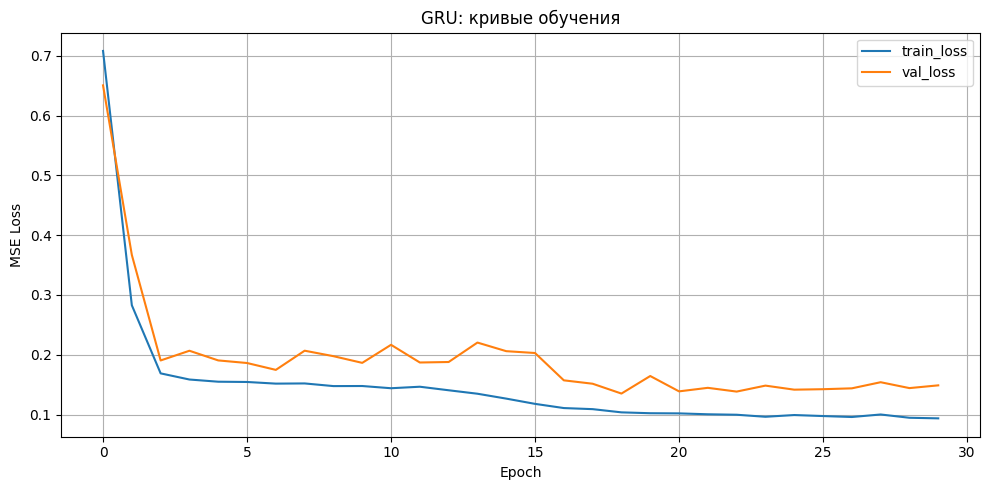

Сохранено: artifacts/figures/gru_learning_curves.png


In [17]:
# Кривые обучения GRU
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("GRU: кривые обучения")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "gru_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/figures/gru_learning_curves.png")

In [18]:
# Предсказания GRU
@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()
    preds, targets = [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).cpu().numpy()
        preds.append(outputs)
        targets.append(y_batch.numpy())
    return np.concatenate(preds), np.concatenate(targets)

def inverse_scale(values_1d, scaler):
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()

# Validation
gru_val_pred_sc, gru_val_true_sc = predict_model(gru_model, val_loader, device)
gru_val_pred = inverse_scale(gru_val_pred_sc, scaler_gru)
gru_val_true = inverse_scale(gru_val_true_sc, scaler_gru)

# Test
gru_test_pred_sc, gru_test_true_sc = predict_model(gru_model, test_loader, device)
gru_test_pred = inverse_scale(gru_test_pred_sc, scaler_gru)
gru_test_true = inverse_scale(gru_test_true_sc, scaler_gru)

r1_val = evaluate(gru_val_true, gru_val_pred, "R1: gru-forecast")
r1_test = evaluate(gru_test_true, gru_test_pred, "R1: gru-forecast")

print("R1 Validation:", {k: round(v, 4) if isinstance(v, float) else v for k, v in r1_val.items()})
print("R1 Test:      ", {k: round(v, 4) if isinstance(v, float) else v for k, v in r1_test.items()})

R1 Validation: {'model': 'R1: gru-forecast', 'MAE': 5.2913, 'RMSE': 6.7822, 'MAPE_%': 3.5773}
R1 Test:       {'model': 'R1: gru-forecast', 'MAE': 6.2471, 'RMSE': 7.9253, 'MAPE_%': 4.0115}


## 11. Сравнение моделей

In [19]:
# Сводная таблица по validation
val_results = pd.DataFrame([b1_val, b2_val, b3_val, r1_val])
val_results = val_results.sort_values("MAE").reset_index(drop=True)
print("=== Результаты на VALIDATION ===")
display(val_results)

# Лучшая модель по MAE на validation
best_model_name = val_results.iloc[0]["model"]
print(f"\nЛучшая модель по val MAE: {best_model_name}")

=== Результаты на VALIDATION ===


,model,MAE,RMSE,MAPE_%
0,R1: gru-forecast,5.291275,6.782225,3.577307
1,B3: ridge-lag-features,6.033327,7.499616,4.042128
2,B1: naive-last,6.443406,8.203532,4.394594
3,B2: moving-average,12.723717,15.236326,8.828779



Лучшая модель по val MAE: R1: gru-forecast


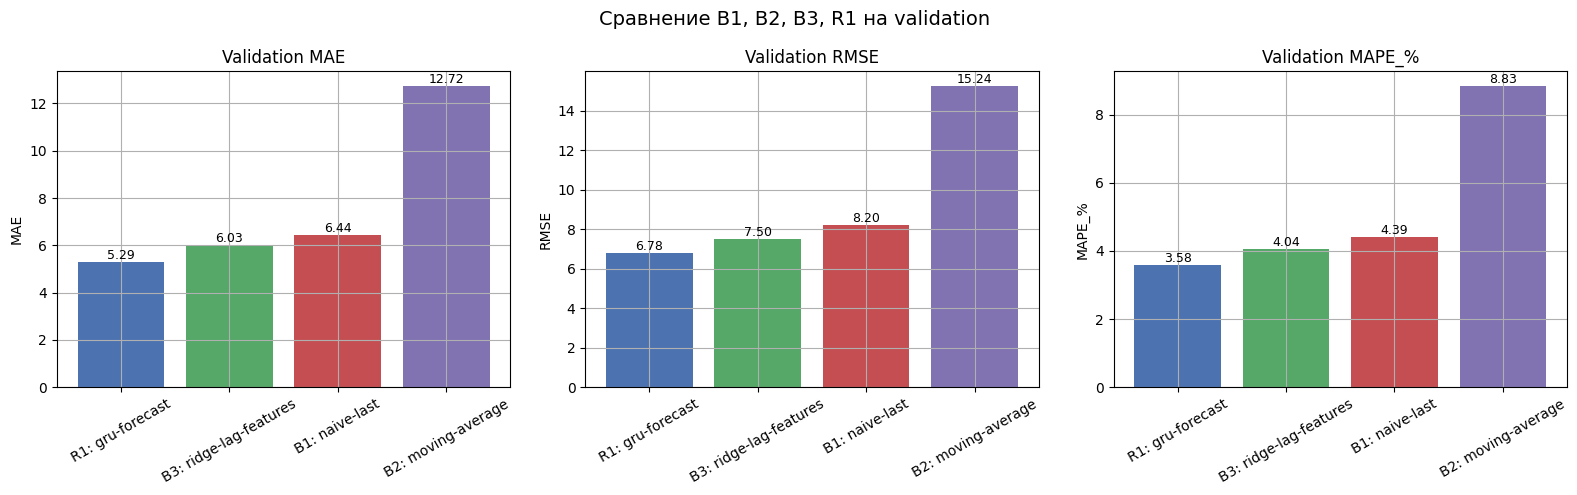

Сохранено: artifacts/figures/baselines_compare.png


In [20]:
# Сравнительный bar-chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = val_results["model"].tolist()
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE_%"]):
    values = val_results[metric].tolist()
    bars = ax.bar(models, values, color=colors[:len(models)])
    ax.set_title(f"Validation {metric}")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{val:.2f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Сравнение B1, B2, B3, R1 на validation", fontsize=14)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "baselines_compare.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/figures/baselines_compare.png")

## 12. Финальная оценка лучшей модели на test

In [21]:
# Тест-метрики всех моделей (для runs.csv), но выбор сделан по validation
test_results = pd.DataFrame([b1_test, b2_test, b3_test, r1_test])
test_results = test_results.sort_values("MAE").reset_index(drop=True)
print("=== Результаты на TEST ===")
display(test_results)

print(f"\nЛучшая модель (выбрана по validation): {best_model_name}")

=== Результаты на TEST ===


,model,MAE,RMSE,MAPE_%
0,B3: ridge-lag-features,6.101912,7.647250,3.921874
1,R1: gru-forecast,6.247052,7.925319,4.011490
2,B1: naive-last,6.338019,8.059906,4.143508
3,B2: moving-average,12.725250,15.226179,8.534403



Лучшая модель (выбрана по validation): R1: gru-forecast


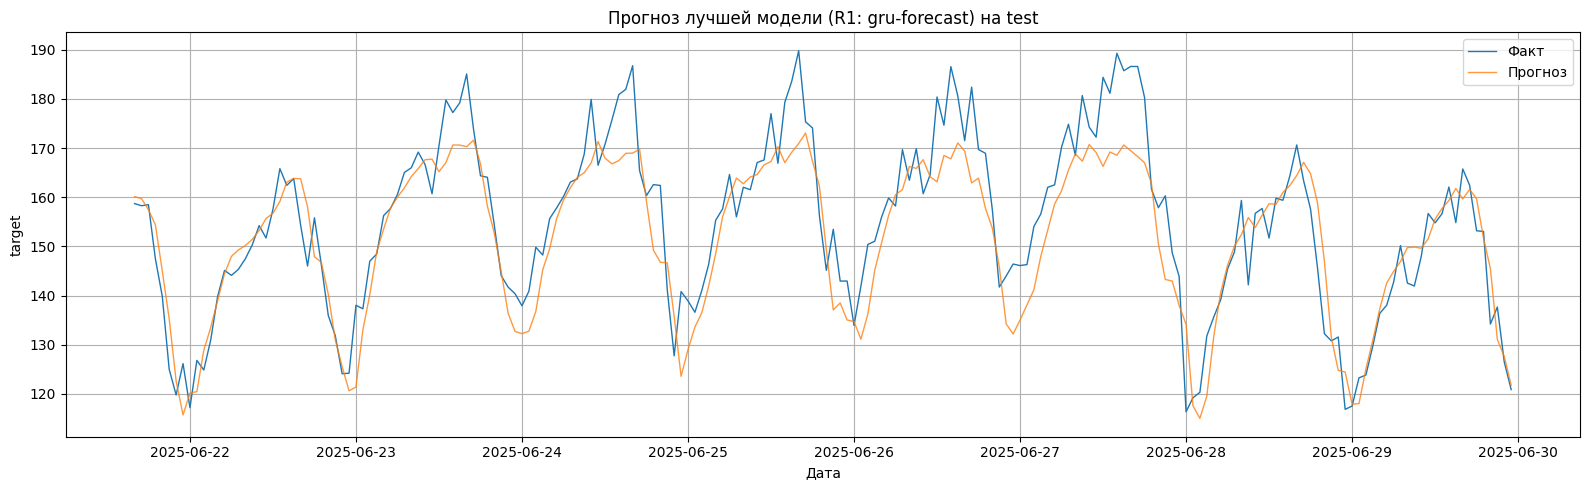

Сохранено: artifacts/figures/best_forecast_test.png


In [22]:
# Визуализация прогноза лучшей модели на test
# Определяем прогноз лучшей модели для визуализации
best_test_pred_map = {
    "B1: naive-last": (test_feat["date"].values, y_test_b3, test_pred_b1),
    "B2: moving-average": (test_feat["date"].values, y_test_b3, test_pred_b2),
    "B3: ridge-lag-features": (test_feat["date"].values, y_test_b3, test_pred_b3),
    "R1: gru-forecast": (
        test_df["date"].values[WINDOW_SIZE:WINDOW_SIZE + len(gru_test_true)],
        gru_test_true,
        gru_test_pred,
    ),
}

dates_best, true_best, pred_best = best_test_pred_map[best_model_name]

# Показываем последние 200 точек для наглядности
n_show = min(200, len(true_best))
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(dates_best[-n_show:], true_best[-n_show:], label="Факт", linewidth=1)
ax.plot(dates_best[-n_show:], pred_best[-n_show:], label="Прогноз", linewidth=1, alpha=0.8)
ax.set_title(f"Прогноз лучшей модели ({best_model_name}) на test")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "best_forecast_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/figures/best_forecast_test.png")

## 13. Сохранение артефактов

In [23]:
# Сохраняем лучшую GRU модель
torch.save(gru_model.state_dict(), ARTIFACTS_DIR / "best_gru.pt")
print("Сохранено: artifacts/best_gru.pt")

# Конфиг GRU
gru_config = {
    "model": "GRUForecaster",
    "input_size": 1,
    "hidden_size": GRU_HIDDEN,
    "num_layers": GRU_LAYERS,
    "dropout": GRU_DROPOUT,
    "window_size": WINDOW_SIZE,
    "batch_size": BATCH_SIZE,
    "learning_rate": GRU_LR,
    "epochs": GRU_EPOCHS,
    "optimizer": "Adam",
    "criterion": "MSELoss",
    "scaler": "StandardScaler",
    "seed": SEED,
    "device": str(device),
}

with open(ARTIFACTS_DIR / "best_gru_config.json", "w", encoding="utf-8") as f:
    json.dump(gru_config, f, indent=2, ensure_ascii=False)
print("Сохранено: artifacts/best_gru_config.json")

Сохранено: artifacts/best_gru.pt
Сохранено: artifacts/best_gru_config.json


In [24]:
# Формируем runs.csv
def make_run_row(exp_id, model_summary, val_metrics, test_metrics,
                 features_summary="", window_size="", optimizer="",
                 lr="", epochs_trained="", scaler="", notes=""):
    return {
        "experiment_id": exp_id,
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": window_size,
        "horizon": 1,
        "model_summary": model_summary,
        "features_summary": features_summary,
        "scaler": scaler,
        "optimizer": optimizer,
        "lr": lr,
        "epochs_trained": epochs_trained,
        "best_val_mae": round(val_metrics["MAE"], 4),
        "best_val_rmse": round(val_metrics["RMSE"], 4),
        "best_val_mape": round(val_metrics["MAPE_%"], 4),
        "test_mae": round(test_metrics["MAE"], 4),
        "test_rmse": round(test_metrics["RMSE"], 4),
        "test_mape": round(test_metrics["MAPE_%"], 4),
        "notes": notes,
    }

runs = pd.DataFrame([
    make_run_row("B1", "naive-last (lag_1)", b1_val, b1_test,
                 features_summary="lag_1",
                 notes="Прогноз = предыдущее значение"),
    make_run_row("B2", "moving-average (rolling_mean_7)", b2_val, b2_test,
                 features_summary="rolling_mean_7 (window=7)",
                 notes="Прогноз = скользящее среднее за 7 точек"),
    make_run_row("B3", "Ridge(alpha=1.0)", b3_val, b3_test,
                 features_summary="lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,dayofweek,hour,dow_sin,dow_cos,hour_sin,hour_cos",
                 scaler="StandardScaler",
                 notes="Ridge на лаговых, rolling и календарных признаках"),
    make_run_row("R1", f"GRU(hidden={GRU_HIDDEN},layers={GRU_LAYERS},dropout={GRU_DROPOUT})",
                 r1_val, r1_test,
                 features_summary=f"target (windowed sequence; window_size={WINDOW_SIZE})",
                 window_size=WINDOW_SIZE, optimizer="Adam", lr=GRU_LR,
                 epochs_trained=GRU_EPOCHS, scaler="StandardScaler",
                 notes="GRU на оконном представлении ряда"),
])

runs.to_csv(ARTIFACTS_DIR / "runs.csv", index=False)
print("Сохранено: artifacts/runs.csv")
display(runs)

Сохранено: artifacts/runs.csv


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,train=3024/val=648/test=648,,1,naive-last (lag_1),lag_1,,,,,6.4434,8.2035,4.3946,6.3380,8.0599,4.1435,Прогноз = предыдущее значение
1,B2,forecasting,S12-hw-dataset.csv,42,train=3024/val=648/test=648,,1,moving-average (rolling_mean_7),rolling_mean_7 (window=7),,,,,12.7237,15.2363,8.8288,12.7252,15.2262,8.5344,Прогноз = скользящее среднее за 7 точек
2,B3,forecasting,S12-hw-dataset.csv,42,train=3024/val=648/test=648,,1,Ridge(alpha=1.0),"lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_...",StandardScaler,,,,6.0333,7.4996,4.0421,6.1019,7.6473,3.9219,"Ridge на лаговых, rolling и календарных признаках"
3,R1,forecasting,S12-hw-dataset.csv,42,train=3024/val=648/test=648,48,1,"GRU(hidden=64,layers=2,dropout=0.1)",target (windowed sequence; window_size=48),StandardScaler,Adam,0.0005,30,5.2913,6.7822,3.5773,6.2471,7.9253,4.0115,GRU на оконном представлении ряда


## 14. Обсуждение утечек данных

В данной работе контролировались следующие потенциальные источники утечки (leakage):

1. **Temporal split вместо random split** — данные разбиты строго по времени, модель не видит будущих наблюдений при обучении.

2. **Лаговые признаки через shift()** — все лаги смотрят только назад во времени. Rolling-статистики вычисляются с `shift(1)`, чтобы текущее значение не попало в окно.

3. **Масштабирование только на train** — `StandardScaler` обучается (`fit`) исключительно на обучающей выборке, а `transform` применяется к validation и test.

4. **Выбор модели по validation** — test используется ровно один раз для финальной оценки уже выбранной лучшей модели, что предотвращает оптимистичную оценку через множественное тестирование.

## 15. Итог

Выполнены все обязательные эксперименты (B1, B2, B3, R1). Лучшая модель выбрана по validation MAE, финальная проверка проведена на test один раз. Все артефакты сохранены в `artifacts/`.